# Data cleaning

In [ ]:
import os
os.chdir('../')
print(os.getcwd())

'c:\\Users\\kriti\\Dropbox\\PC\\Desktop\\Ironhack_AI_Engineering\\Projects\\Project_2\\Project-2-Natural-Language-Processing\\notebooks'

In [ ]:
# Core imports
import utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
raw_data = pd.read_csv('dataset/data.csv')
print(raw_data.shape)
#raw_data = raw_data.head(1000)
raw_data = raw_data.drop(columns=['subject', 'date'])
print(raw_data.shape)
raw_data

(39942, 5)
(39942, 3)


,label,title,text
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...
...,...,...,...
39937,0,THIS IS NOT A JOKE! Soros-Linked Group Has Pla...,"The Left has been organizing for decades, and ..."
39938,0,THE SMARTEST WOMAN In Politics: “How Trump Can...,Monica Crowley offers some of the most brillia...
39939,0,BREAKING! SHOCKING VIDEO FROM CHARLOTTE RIOTS:...,Protest underway in Charlotte: Things got com...
39940,0,BREAKING! Charlotte News Station Reports Cops ...,"Local Charlotte, NC news station WSOCTV is rep..."


# data cleaning

In [ ]:
# # Your code
# from nltk.tokenize import word_tokenize
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer 
# # Your code
from sklearn.model_selection import train_test_split

# # Your code
# import re

In [7]:
# Features (emails)
X = raw_data.drop(columns='label')
# Labels (0 = legitimate, 1 = fraudulent)
y = raw_data["label"]

# Split the raw_dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y      # Keeps the same class distribution
)

In [8]:
def clean_data(text):
    # 1. Remove inline JavaScript
    text = re.sub(r'<script.*?>.*?</script>', '', text, flags=re.DOTALL | re.IGNORECASE)

    # 2. Remove inline CSS
    text = re.sub(r'<style.*?>.*?</style>', '', text, flags=re.DOTALL | re.IGNORECASE)

    # 3. Remove HTML comments
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)

    # 4. Remove all remaining HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remove URLS
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove all the special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove all single characters
    text = re.sub(r'\b[a-zA-Z]\b', ' ', text)

    # Remove single characters from the start
    text = re.sub(r'^\s*[a-zA-Z]\s+', '', text)

    # Substitute multiple spaces with single space
    text = re.sub(r'\s+', ' ', text)

    # Remove prefixed 'b'
    text = re.sub(r'^b\s+', '', text)

    # Convert to Lowercase
    text = text.lower()

    return text


In [9]:
# X_train['clean_title'] = X_train['title'].apply(clean_data)
# X_train['clean_text'] = X_train['text'].apply(clean_data)

# X_test['clean_title'] = X_test['title'].apply(clean_data)
# X_test['clean_text'] = X_test['text'].apply(clean_data)

# X_train

In [10]:
def preprocess_data(text):
    # Tokenize the email
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words("english"))
    filtered_tokens = []

    for word in tokens:
        if word.lower() not in stop_words:
            filtered_tokens.append(word)
    
    # Lemmetization
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens ] 

    # Join the tokens back into a string
    return " ".join(lemmatized_tokens)

In [11]:
# X_train['clean_title_prerocessed'] = X_train['clean_title'].apply(preprocess_data)
# X_train['clean_text_prerocessed'] = X_train['clean_text'].apply(preprocess_data)

# X_test['clean_title_prerocessed'] = X_test['clean_title'].apply(preprocess_data)
# X_test['clean_text_prerocessed'] = X_test['clean_text'].apply(preprocess_data)

# X_train

In [12]:
# X_train_clean = X_train[['clean_title_prerocessed', 'clean_text_prerocessed']]
# X_train_clean.columns = ['title', 'text']

# X_test_clean = X_test[['clean_title_prerocessed', 'clean_text_prerocessed']]
# X_test_clean.columns = ['title', 'text']

# X_train_clean

In [13]:
# X_train_clean.to_csv('X_train_clean.csv')
# X_test_clean.to_csv('X_test_clean.csv')

In [ ]:
TEXT_COLUMNS = ['title', 'text']


# read train and test

In [82]:
X_train_clean = pd.read_csv('X_train_clean.csv', index_col=0)
X_test_clean = pd.read_csv('X_test_clean.csv', index_col=0)

X_train_clean

,title,text
33231,must see house oversight committee release dam...,crooked lying hillary
36761,scalia found dead pillow head millionaire demo...,justice scalia appeared good health prior vaca...
29035,road raging texas good guy gun shoot woman hea...,university north texas student critical condit...
31791,firebenstein fox news ben stein call president...,NaN
3419,exclusive special counsel mueller probe ex tru...,washington reuters robert mueller special coun...
...,...,...
33001,radical anti gun muslim state senator arrested...,october radical muslim state senator jamilah r...
13185,german police check suspicious parcel potsdam ...,berlin reuters german police monday investigat...
1334,mexico remain nafta good national interest for...,mexico city reuters mexico remain within north...
32958,trump falsely accused encouraging police racia...,trump actually said police amazing local polic...


In [48]:
any(y_train.index == X_train.index)

True

In [83]:
X_train_clean.isna().sum()

title      5
text     549
dtype: int64

In [84]:
X_test_clean.isna().sum()

title      2
text     144
dtype: int64

In [85]:
X_train_clean.loc[35507,:]

title    NaN
text     NaN
Name: 35507, dtype: str

## Fill null values with empty string ' '
- after cleaning and preprocessing text - null values foound.
- fill with empty strings

In [86]:
X_train_clean = X_train_clean.fillna('')
X_test_clean = X_test_clean.fillna('')

X_train_clean.isna().sum().sum(), X_test_clean.isna().sum().sum()

(np.int64(0), np.int64(0))

In [19]:
k

NameError: name 'k' is not defined

In [81]:
X_train_clean.isna().sum().sum(), X_test_clean.isna().sum().sum()

(np.int64(554), np.int64(146))

# tfidf

In [87]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from scipy.sparse import hstack
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
# tfidf_vectorizer = TfidfVectorizer() 

# X_train_tfidf_title = tfidf_vectorizer.fit_transform(X_train_clean['title'])
# X_test_tfidf_title = tfidf_vectorizer.transform(X_test_clean['title'])

# X_train_tfidf_text = tfidf_vectorizer.fit_transform(X_train_clean['text'])
# X_test_tfidf_text = tfidf_vectorizer.transform(X_test_clean['text'])


In [88]:
TEXT_COLUMNS = ['title', 'text']

# --- TF-IDF per text column ---
tfidf_vectorizers = {}
X_train_text_features = []
X_test_text_features = []

for col in TEXT_COLUMNS:
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2)) # # max_features=5000, ngram_range=(1,2)
    train_vec = vectorizer.fit_transform(X_train_clean[col])
    test_vec = vectorizer.transform(X_test_clean[col])

    tfidf_vectorizers[col] = vectorizer
    X_train_text_features.append(train_vec)
    X_test_text_features.append(test_vec)

    print(f"{col}: train shape {train_vec.shape}, test shape {test_vec.shape}")


title: train shape (31953, 5000), test shape (7989, 5000)
text: train shape (31953, 5000), test shape (7989, 5000)


### OG tf-idf vectorizer shape
- ``title: train shape (31953, 15682), test shape (7989, 15682)`` --> *15682* words
- ``text: train shape (31953, 86540), test shape (7989, 86540)`` --> *86540* words

In [ ]:
#train_vec.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(31953, 86540))

In [89]:
tfidf_vectorizers['text']

,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None


In [90]:
# --- Combine all features ---
X_train_final = hstack(X_train_text_features)
X_test_final = hstack(X_test_text_features)

print("Final train feature matrix:", X_train_final.shape)
print("Final test feature matrix:", X_test_final.shape)

Final train feature matrix: (31953, 10000)
Final test feature matrix: (7989, 10000)


## model training

## reusable function

In [91]:
import json
import os
from datetime import datetime

RESULTS_FILE = "results_log.jsonl"   # one JSON object per line, easy to append to


def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Predict on train and test data and compute evaluation metrics.
    Returns a dict of metrics + the confusion matrix (test-based).
    """
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = {
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'precision': precision_score(y_test, y_test_pred, zero_division=0),
        'recall': recall_score(y_test, y_test_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_test_pred, zero_division=0),
        'confusion_matrix': confusion_matrix(y_test, y_test_pred),
        'y_pred': y_test_pred,
    }
    return metrics


def save_result_to_file(result, filepath=RESULTS_FILE):
    """
    Append a single result to a JSONL file (one JSON object per line).
    Excludes non-serializable objects (fitted model, y_pred array).
    Safe to call repeatedly — appends, never overwrites.
    """
    serializable_result = {
        'timestamp': result['timestamp'],
        'model_name': result['model_name'],
        'method': result['method'],
        'comments': result['comments'],
        'train_accuracy': result['train_accuracy'],
        'test_accuracy': result['test_accuracy'],
        'precision': result['precision'],
        'recall': result['recall'],
        'f1_score': result['f1_score'],
        'confusion_matrix': result['confusion_matrix'].tolist(),  # np.array -> list for JSON
    }

    with open(filepath, 'a') as f:
        f.write(json.dumps(serializable_result) + "\n")


def train_evaluate_model(model, method, model_name, X_train, y_train, X_test, y_test,
                          comments="", results_container=None,
                          save_to_file=True, filepath=RESULTS_FILE):
    """
    Super-function: trains, predicts, evaluates, and optionally stores results
    in-memory (results_container) and/or on disk (filepath), so results persist
    across notebook restarts.

    Parameters
    ----------
    model : sklearn-like estimator (must implement .fit and .predict)
    model_name : str, name/label for this run (e.g. "Logistic Regression")
    method : str, feature-extraction method used (e.g. "TF-IDF")
    comments : str, free-text notes (e.g. hyperparameters, feature set used)
    results_container : list, optional. If provided, the result dict is appended to it.
    save_to_file : bool, whether to append this result to disk immediately (default True)
    filepath : str, path to the JSONL results log file

    Returns
    -------
    result : dict with keys:
        timestamp, model_name, method, comments, train_accuracy, test_accuracy,
        precision, recall, f1_score, confusion_matrix, model (fitted object)
    """
    fitted_model = model.fit(X_train, y_train)
    metrics = evaluate_model(fitted_model, X_train, y_train, X_test, y_test)

    result = {
        'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'model_name': model_name,
        'method': method,
        'comments': comments,
        'train_accuracy': metrics['train_accuracy'],
        'test_accuracy': metrics['test_accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1_score': metrics['f1_score'],
        'confusion_matrix': metrics['confusion_matrix'],
        'model': fitted_model,
    }

    print(f"--- {model_name} | {method} ({comments}) ---")
    print(f"Train Accuracy: {result['train_accuracy']:.4f}")
    print(f"Test Accuracy:  {result['test_accuracy']:.4f}")
    print(f"Precision:      {result['precision']:.4f}")
    print(f"Recall:         {result['recall']:.4f}")
    print(f"F1 Score:       {result['f1_score']:.4f}")
    print("Confusion Matrix:\n", result['confusion_matrix'])
    print()

    if results_container is not None:
        results_container.append(result)

    if save_to_file:
        save_result_to_file(result, filepath=filepath)

    return result


def load_results_from_file(filepath=RESULTS_FILE):
    """Load all saved results from the JSONL file into a DataFrame."""
    if not os.path.exists(filepath):
        return pd.DataFrame()

    records = []
    with open(filepath, 'r') as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

# usage:
# results_df = load_results_from_file()
# results_df.sort_values('f1_score', ascending=False)

## train models


In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC


In [93]:
print(X_train_final.shape, y_train.shape)
print(X_test_final.shape, y_test.shape)

(31953, 10000) (31953,)
(7989, 10000) (7989,)


In [94]:
# Container to collect results from every model we try below
RESULTS = []


In [95]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_results = train_evaluate_model(
    lr_model, 'TF-IDF', 'Logistic Regression - TF-IDF',
    X_train_final, y_train, X_test_final, y_test,
    comments="Baseline LR model with tfidf(5000 features, ngram_range=(1,2))", 
    results_container=RESULTS
    )

--- Logistic Regression - TF-IDF | TF-IDF (Baseline LR model with tfidf(5000 features, ngram_range=(1,2))) ---
Train Accuracy: 0.9968
Test Accuracy:  0.9919
Precision:      0.9908
Recall:         0.9930
F1 Score:       0.9919
Confusion Matrix:
 [[3952   37]
 [  28 3972]]



In [96]:
nb_model = MultinomialNB()
nb_results = train_evaluate_model(
    nb_model, 'TF-IDF', 'Naive Bayes - TF-IDF',
    X_train_final, y_train, X_test_final, y_test,
    comments="Naive Bayes model with tfidf(5000 features, ngram_range=(1,2))", 
    results_container=RESULTS
    )

--- Naive Bayes - TF-IDF | TF-IDF (Naive Bayes model with tfidf(5000 features, ngram_range=(1,2))) ---
Train Accuracy: 0.9614
Test Accuracy:  0.9551
Precision:      0.9589
Recall:         0.9510
F1 Score:       0.9549
Confusion Matrix:
 [[3826  163]
 [ 196 3804]]



In [97]:
svm_model = LinearSVC()
svm_results = train_evaluate_model(
    svm_model, 'TF-IDF', 'SVM - TF-IDF',
    X_train_final, y_train, X_test_final, y_test,
    comments="SVM model with tfidf(5000 features, ngram_range=(1,2))", 
    results_container=RESULTS
    )

--- SVM - TF-IDF | TF-IDF (SVM model with tfidf(5000 features, ngram_range=(1,2))) ---
Train Accuracy: 1.0000
Test Accuracy:  0.9957
Precision:      0.9953
Recall:         0.9962
F1 Score:       0.9958
Confusion Matrix:
 [[3970   19]
 [  15 3985]]



In [ ]:
# rf_model = RandomForestClassifier(random_state=42)
# rf_results = train_evaluate_model(
#     rf_model, 'TF-IDF', 'Random Forest - TF-IDF',
#     X_train_final, y_train, X_test_final, y_test,
#     comments="Random Forest model with tfidf(5000 features)", 
#     results_container=RESULTS
#     )

# # time = 1m

--- Random Forest - TF-IDF | TF-IDF (Random Forest model with tfidf(5000 features)) ---
Train Accuracy: 1.0000
Test Accuracy:  0.9970
Precision:      0.9980
Recall:         0.9960
F1 Score:       0.9970
Confusion Matrix:
 [[3981    8]
 [  16 3984]]



# comparison models

In [ ]:
results_df = load_results_from_file()
results_df.sort_values('f1_score', ascending=False)

,timestamp,model_name,method,comments,train_accuracy,test_accuracy,precision,recall,f1_score,confusion_matrix
11,2026-07-09 16:23:06,Random Forest - TF-IDF,TF-IDF,COMBINED text Random Forest model with tfidf(5...,1.000000,0.997622,0.997998,0.99725,0.997624,"[[3981, 8], [11, 3989]]"
7,2026-07-09 15:39:01,Random Forest - TF-IDF,TF-IDF,Random Forest model with tfidf(5000 features),1.000000,0.996996,0.997996,0.99600,0.996997,"[[3981, 8], [16, 3984]]"
3,2026-07-09 15:29:25,Random Forest - TF-IDF,TF-IDF,Random Forest model with tfidf(5000 features),1.000000,0.996996,0.997996,0.99600,0.996997,"[[3981, 8], [16, 3984]]"
2,2026-07-09 15:28:18,SVM - TF-IDF,TF-IDF,SVM model with tfidf(5000 features),0.999969,0.995744,0.994760,0.99675,0.995754,"[[3968, 21], [13, 3987]]"
6,2026-07-09 15:37:54,SVM - TF-IDF,TF-IDF,SVM model with tfidf(5000 features),0.999969,0.995744,0.994760,0.99675,0.995754,"[[3968, 21], [13, 3987]]"
14,2026-07-09 16:37:22,SVM - TF-IDF,TF-IDF,"SVM model with tfidf(5000 features, ngram_rang...",0.999969,0.995744,0.995255,0.99625,0.995752,"[[3970, 19], [15, 3985]]"
17,2026-07-09 16:45:55,SVM - TF-IDF,TF-IDF,COMBINED -no preprocessing - SVM model with t...,0.998936,0.993616,0.993502,0.99375,0.993626,"[[3963, 26], [25, 3975]]"
10,2026-07-09 16:22:07,SVM - TF-IDF,TF-IDF,COMBINED text SVM model with tfidf(5000 features),0.998905,0.993616,0.993502,0.99375,0.993626,"[[3963, 26], [25, 3975]]"
12,2026-07-09 16:37:16,Logistic Regression - TF-IDF,TF-IDF,"Baseline LR model with tfidf(5000 features, ng...",0.996839,0.991864,0.990771,0.99300,0.991884,"[[3952, 37], [28, 3972]]"
0,2026-07-09 15:27:56,Logistic Regression - TF-IDF,TF-IDF,Baseline LR model with tfidf(5000 features),0.996244,0.990612,0.988549,0.99275,0.990645,"[[3943, 46], [29, 3971]]"


In [ ]:
# results_df = pd.DataFrame([
#     {k: v for k, v in r.items() if k not in ('confusion_matrix', 'model')}
#     for r in results
# ])
# results_df = results_df.sort_values('f1_score', ascending=False).reset_index(drop=True)
# results_df


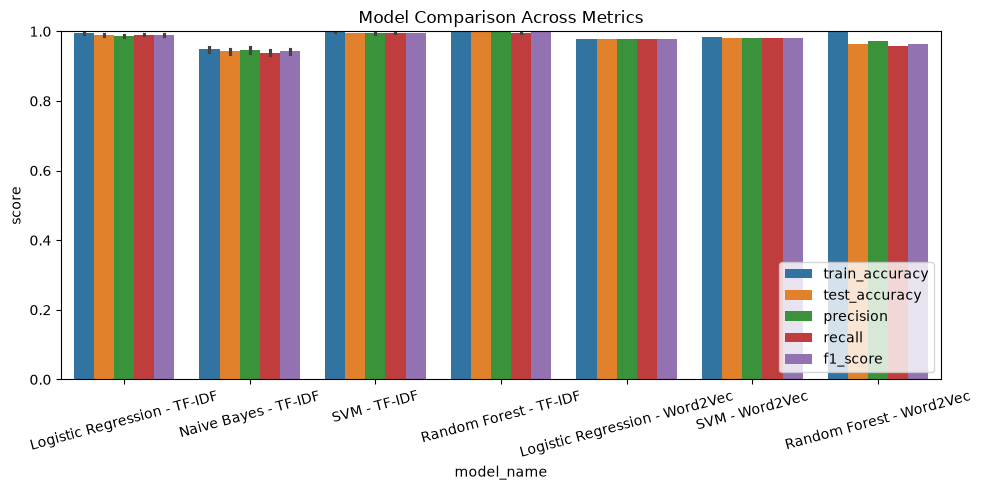

In [ ]:
# --- Bar plot comparing metrics across models ---
metrics_to_plot = ['train_accuracy', 'test_accuracy', 'precision', 'recall', 'f1_score']
plot_df = results_df.melt(id_vars='model_name', value_vars=metrics_to_plot,
                           var_name='metric', value_name='score')

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x='model_name', y='score', hue='metric')
plt.title('Model Comparison Across Metrics')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


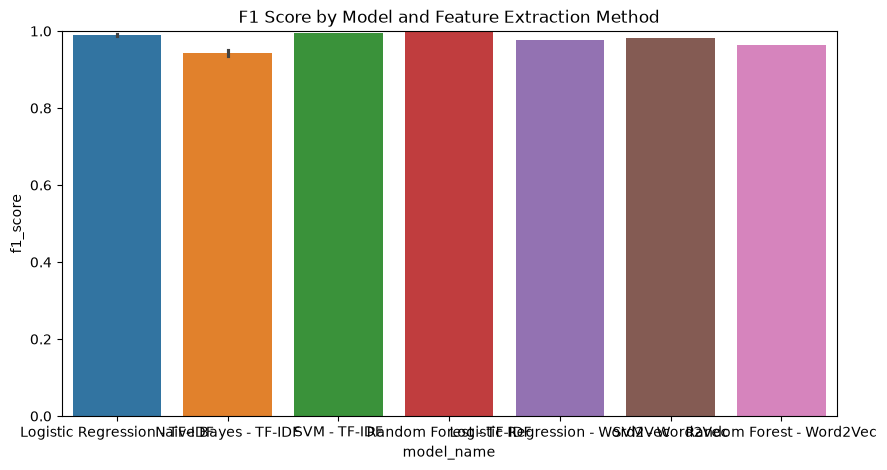

In [ ]:
#--- Grouped bar plot: F1 score by model, grouped by feature method ---
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='model_name', y='f1_score', hue='model_name')
plt.title('F1 Score by Model and Feature Extraction Method')
plt.ylim(0,1)
plt.show()

In [ ]:
# # --- Confusion matrices side by side ---
# fig, axes = plt.subplots(1, len(results_df), figsize=(5 * len(results_df), 4))
# if len(results_df) == 1:
#     axes = [axes]

# for ax, r in zip(axes, results_df):
#     sns.heatmap(r['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=ax)
#     ax.set_title(r['model_name'])
#     ax.set_xlabel('Predicted')
#     ax.set_ylabel('Actual')

# plt.tight_layout()
# plt.show()


In [ ]:
# --- Best model selection ---
best_row = results_df.iloc[0]
print(f"Best model based on F1 Score: {best_row['model_name']} "
      f"(F1={best_row['f1_score']:.4f}, Accuracy={best_row['accuracy']:.4f})")
